# Session 3 Assignment — Statistical Reasoning with Olist

**Student:** Molemi Molokoane

**Question in one line:** Do customers whose orders arrive late give lower review scores than customers whose orders arrive on time?

## 1. Research Question

> **Is late delivery associated with lower customer review scores on Olist?**

An order counts as **late** if the customer received it after the delivery date Olist estimated at purchase.

**What I expect before looking at the data:** customers usually care a lot about delivery, so I expect late orders to get noticeably lower review scores.

**Hypotheses**

- **H₀ (null):** Review scores are distributed the same way for late and on-time orders.
- **H₁ (alternative):** Review scores differ between late and on-time orders.

## 2. Variables

| Variable | Source table | Type | Meaning |
|---|---|---|---|
| `order_status` | orders | categorical | Used to keep only orders that were delivered |
| `order_delivered_customer_date` | orders | datetime | When the customer actually received the order |
| `order_estimated_delivery_date` | orders | datetime | The delivery date promised to the customer at purchase |
| `delay_days` *(derived)* | orders | numerical (continuous) | `delivered − estimated`, in days. Negative = early, positive = late |
| `is_late` *(derived)* | orders | categorical (binary) | `True` if `delay_days > 0` |
| `review_score` | order_reviews | ordinal (1–5) | The customer's star rating of the order |

**What one row represents:** after the join, one row is **one delivered order with one review**.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr

sns.set_theme(style="whitegrid")

In [2]:
dataset_path = "../Olist Dataset"   # change this to your Google Drive path if running in Colab

orders = pd.read_csv(
    os.path.join(dataset_path, "olist_orders_dataset.csv"),
    parse_dates=["order_purchase_timestamp",
                 "order_delivered_customer_date",
                 "order_estimated_delivery_date"]
)
reviews = pd.read_csv(os.path.join(dataset_path, "olist_order_reviews_dataset.csv"))

print("orders :", orders.shape)
print("reviews:", reviews.shape)

orders : (99441, 8)
reviews: (99224, 7)


### Preparing the data

Three cleaning decisions:

1. **Delivered orders only.** Cancelled or undelivered orders have no delivery date, so lateness cannot be measured.
2. **Drop missing delivery dates.** A few "delivered" orders have no delivery timestamp.
3. **One review per order.** Some orders have more than one review. I keep the most recent answer so that no order is counted twice.

In [3]:
print("Orders with more than one review:",
      (reviews["order_id"].value_counts() > 1).sum())

reviews_one = (
    reviews
    .sort_values("review_answer_timestamp")
    .drop_duplicates("order_id", keep="last")
    [["order_id", "review_score"]]
)

delivered = orders[orders["order_status"] == "delivered"].dropna(
    subset=["order_delivered_customer_date"]
)

df = delivered.merge(reviews_one, on="order_id", how="inner")

df["delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400
df["is_late"] = df["delay_days"] > 0

print("Delivered orders with a review:", len(df))
df[["order_id", "order_delivered_customer_date",
    "order_estimated_delivery_date", "delay_days", "is_late", "review_score"]].head()

Orders with more than one review: 547


Delivered orders with a review: 95824


,order_id,order_delivered_customer_date,order_estimated_delivery_date,delay_days,is_late,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,-7.107488,False,4
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,-5.355729,False,4
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,-17.245498,False,5
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,-12.980069,False,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,-9.238171,False,5


## 3. Exploratory Analysis

### 3.1 How common are late deliveries?

This checks whether the classes are balanced (see the *Unbalanced Data* section of the lesson).

In [4]:
late_counts = df["is_late"].value_counts().rename({False: "On time / early", True: "Late"})
print(late_counts)
print()
print((df["is_late"].value_counts(normalize=True) * 100).round(1).rename({False: "On time / early %", True: "Late %"}))

is_late
On time / early    88163
Late                7661
Name: count, dtype: int64

is_late
On time / early %    92.0
Late %                8.0
Name: proportion, dtype: float64


Only about **8%** of orders are late, so the groups are very unbalanced (roughly 88,000 vs 7,700). The late group is still large, so there is enough data to compare them. I should compare **proportions and distributions**, not raw counts.

### 3.2 Distribution of the delivery delay

In [5]:
df["delay_days"].describe()

count    95824.000000
mean       -11.215213
std         10.114097
min       -146.016123
25%        -16.248435
50%        -11.973050
75%         -6.407182
max        188.975081
Name: delay_days, dtype: float64

In [6]:
Q1, Q3 = df["delay_days"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df["delay_days"] < lower) | (df["delay_days"] > upper)]

print(f"Mean delay  : {df['delay_days'].mean():.2f} days")
print(f"Median delay: {df['delay_days'].median():.2f} days")
print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"Outlier fences: below {lower:.2f} or above {upper:.2f} days")
print(f"Potential outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of orders)")

Mean delay  : -11.22 days
Median delay: -11.97 days
Q1 = -16.25, Q3 = -6.41, IQR = 9.84
Outlier fences: below -31.01 or above 8.35 days
Potential outliers: 4780 (5.0% of orders)


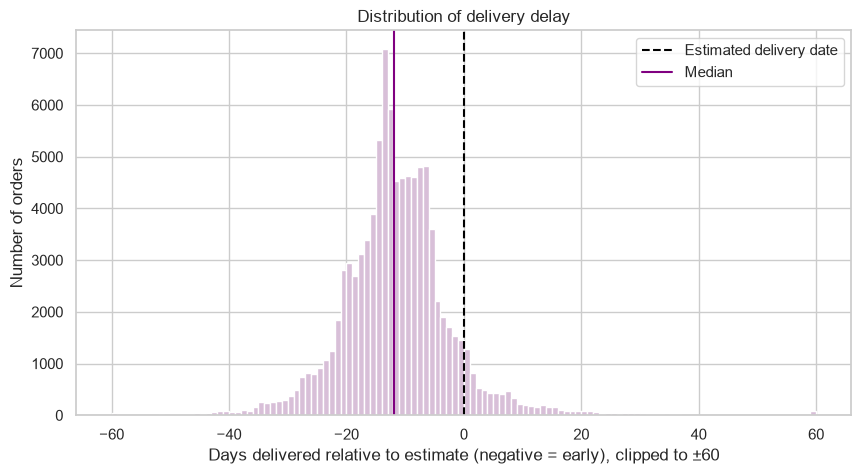

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["delay_days"].clip(-60, 60), bins=120, color="thistle", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", label="Estimated delivery date")
ax.axvline(df["delay_days"].median(), color="purple", label="Median")
ax.set_xlabel("Days delivered relative to estimate (negative = early), clipped to ±60")
ax.set_ylabel("Number of orders")
ax.set_title("Distribution of delivery delay")
ax.legend()
plt.show()

**What I notice:**

- Most orders arrive **before** the estimate. The median order arrives about **12 days early**, so Olist's estimates are conservative.
- Mean and median are close (about −11.2 vs −12.0 days), so the middle of the distribution is fairly symmetric. The tails are long, though: some orders arrived months early, and a few more than 100 days late.
- The outliers are probably real events (lost parcels, logistics problems), not data errors, so I **keep them**. The method I use in Section 4 is based on ranks, so extreme values have little effect on it.

### 3.3 Distribution of review scores

In [8]:
df["review_score"].describe()

count    95824.00000
mean         4.15588
std          1.28481
min          1.00000
25%          4.00000
50%          5.00000
75%          5.00000
max          5.00000
Name: review_score, dtype: float64

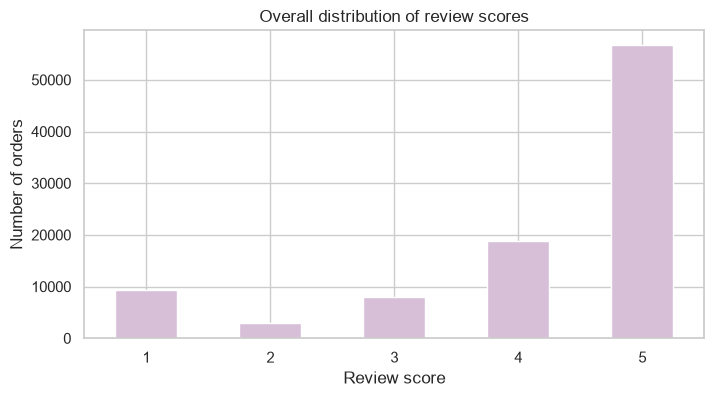

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
df["review_score"].value_counts().sort_index().plot(kind="bar", color="thistle", ax=ax)
ax.set_xlabel("Review score")
ax.set_ylabel("Number of orders")
ax.set_title("Overall distribution of review scores")
ax.tick_params(axis="x", rotation=0)
plt.show()

Review scores are **negatively (left) skewed**. Most customers give 5 stars, followed by 4 stars, with a smaller second peak at 1 star. The median (5) is above the mean (≈4.2), which is typical for left-skewed data. Review score is **ordinal**: the gap between 1 and 2 stars is not necessarily the same as the gap between 4 and 5. This affects which test is appropriate.

### 3.4 Comparing the two groups

In [10]:
summary = df.groupby("is_late")["review_score"].agg(
    count="count", mean="mean", median="median",
    q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75), std="std"
).rename(index={False: "On time / early", True: "Late"})
summary.round(2)

,count,mean,median,q1,q3,std
is_late,,,,,,
On time / early,88163,4.29,5.0,4.0,5.0,1.15
Late,7661,2.57,2.0,1.0,4.0,1.66


In [11]:
score_share = (
    pd.crosstab(df["is_late"], df["review_score"], normalize="index") * 100
).rename(index={False: "On time / early", True: "Late"})
score_share.round(1)

review_score,1,2,3,4,5
is_late,,,,,
On time / early,6.6,2.6,8.0,20.4,62.4
Late,46.2,7.9,11.4,12.3,22.2


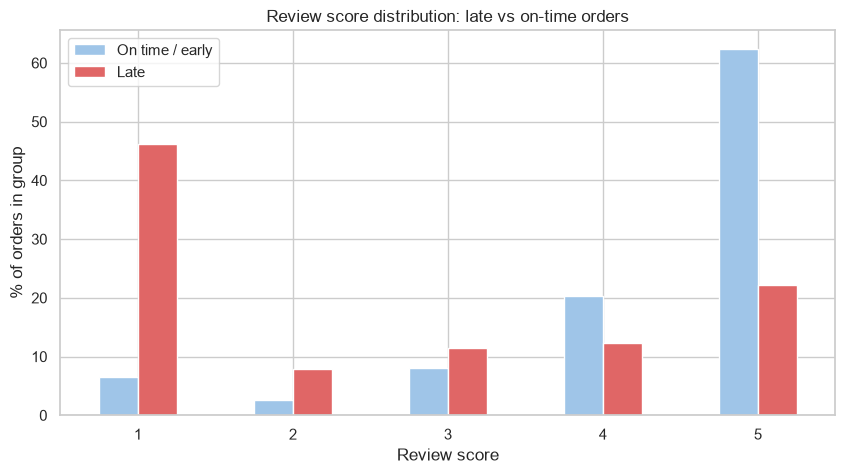

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
score_share.T.plot(kind="bar", ax=ax, color=["#9fc5e8", "#e06666"])
ax.set_xlabel("Review score")
ax.set_ylabel("% of orders in group")
ax.set_title("Review score distribution: late vs on-time orders")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="")
plt.show()

The difference is large:

- **On-time orders:** about 62% give 5 stars and only about 7% give 1 star. Median = 5.
- **Late orders:** about **46% give 1 star** and only about 22% give 5 stars. Median = 2.

### 3.5 Does it get worse the later the order is?

Grouping `delay_days` into bands lets me check for a dose-response pattern. Seeing one would support the relationship more strongly than a single late/not-late split.

In [13]:
bins = [-np.inf, -14, -7, 0, 3, 7, 14, np.inf]
labels = ["≥14 early", "7–14 early", "0–7 early", "0–3 late", "3–7 late", "7–14 late", ">14 late"]
df["delay_band"] = pd.cut(df["delay_days"], bins=bins, labels=labels)

band_summary = df.groupby("delay_band", observed=True)["review_score"].agg(
    orders="count", mean_score="mean", pct_1_star=lambda s: (s == 1).mean() * 100
)
band_summary.round(2)

,orders,mean_score,pct_1_star
delay_band,,,
≥14 early,34771,4.32,6.54
7–14 early,36158,4.31,6.41
0–7 early,17234,4.20,7.07
0–3 late,2636,3.77,13.77
3–7 late,1773,2.32,53.02
7–14 late,1748,1.74,68.14
>14 late,1504,1.71,69.55


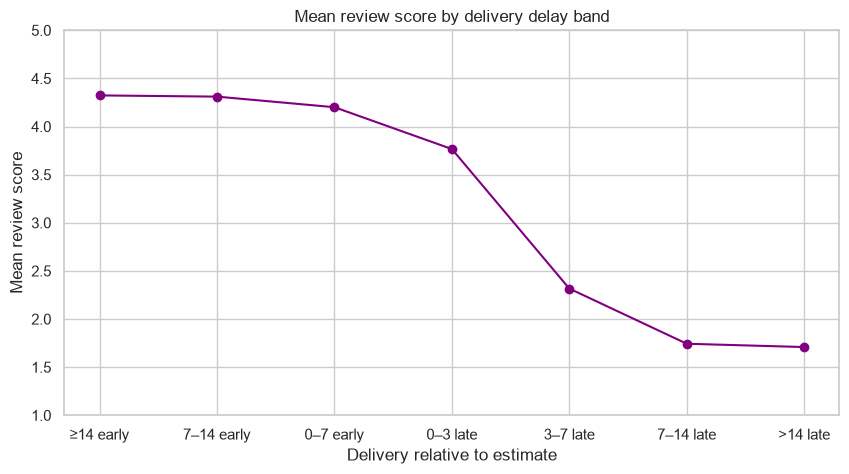

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(band_summary.index.astype(str), band_summary["mean_score"], marker="o", color="purple")
ax.set_ylim(1, 5)
ax.set_xlabel("Delivery relative to estimate")
ax.set_ylabel("Mean review score")
ax.set_title("Mean review score by delivery delay band")
plt.show()

There is a clear **dose-response** pattern. Scores are stable (about 4.3) for any order that arrives before the estimate. They drop sharply once an order is late and keep falling the later it arrives. Orders that are more than two weeks late average below 2 stars.

Arriving *very* early earns only slightly higher scores than arriving just early. What matters most is crossing the promised date.

## 4. Statistical Approach

**The question compares two groups** (late vs on time) on one outcome (review score), so I use a **comparison of groups** with a hypothesis test.

**Why I use the Mann–Whitney U test instead of a t-test:**

- `review_score` is **ordinal** (1–5 stars), not a true continuous measurement, so a mean of stars is only a rough summary.
- Both distributions are **heavily skewed** and nowhere near normal (one piles up at 5, the other at 1).
- Mann–Whitney is **non-parametric**. It compares ranks, so it needs no normality assumption and is robust to skew and outliers.

**Effect size:** with about 96,000 orders, even a tiny difference would come out "statistically significant". So I also report an effect size, the **rank-biserial correlation** (range −1 to +1). It shows how *big* the difference is, not just whether one exists.

**Supporting check:** a **Spearman rank correlation** between `delay_days` (continuous) and `review_score` tests whether the pattern in 3.5 is monotonic. It uses the full delay values instead of a binary split.

## 5. Statistical Test

In [15]:
late_scores = df.loc[df["is_late"], "review_score"]
ontime_scores = df.loc[~df["is_late"], "review_score"]

u_stat, p_value = mannwhitneyu(ontime_scores, late_scores, alternative="two-sided")

n1, n2 = len(ontime_scores), len(late_scores)
rank_biserial = 2 * u_stat / (n1 * n2) - 1   # >0 means on-time orders tend to score higher

print(f"Mann-Whitney U = {u_stat:,.0f}")
print(f"p-value        = {p_value:.3g}")
print(f"Rank-biserial correlation (effect size) = {rank_biserial:.3f}")

Mann-Whitney U = 524,709,892
p-value        = 0
Rank-biserial correlation (effect size) = 0.554


In [16]:
prob_superiority = u_stat / (n1 * n2)
print(f"P(random on-time review > random late review) + 0.5*P(tie) = {prob_superiority:.2f}")

P(random on-time review > random late review) + 0.5*P(tie) = 0.78


In [17]:
rho, p_rho = spearmanr(df["delay_days"], df["review_score"])
print(f"Spearman rho = {rho:.3f}, p-value = {p_rho:.3g}")

Spearman rho = -0.176, p-value = 0


**Results in plain language:**

- **Mann–Whitney p-value ≈ 0** (below the smallest number the computer can represent). If late and on-time orders really had the same distribution of review scores, a gap this large would essentially never appear by chance in a sample this size. **I reject H₀.**
- **Rank-biserial correlation ≈ 0.55.** This is a **large effect**. Put another way: pick one random on-time review and one random late review. The on-time review is higher about **78%** of the time, counting ties as half.
- **Spearman ρ ≈ −0.18.** Across *all* orders, the relationship between delay and score is negative but **weak**. That fits Section 3.5: most orders are early, and scores barely change *within* the early range. The effect is concentrated among the ~8% of late orders.

## 6. Interpretation

- **Late delivery is strongly associated with worse reviews.** The typical (median) review drops from **5 stars to 2 stars** when an order is late, and the share of 1-star reviews rises roughly **7×** (from ~7% to ~46%).
- **The effect is meaningful, not just statistically significant.** A tiny p-value alone would be expected with 96,000 rows. The effect size and the change in medians show the difference is large enough to matter.
- **The promised date works like a threshold.** Arriving 2 days early or 20 days early makes little difference to the score, but arriving after the estimate does. Customers seem to judge delivery **against the promise** more than by the absolute delivery time.
- **Business angle:** keeping the promise matters more than raw delivery speed. Honest (or slightly padded) estimates, and focusing logistics effort on orders at risk of being late, would likely protect review scores.

## 7. Limitations

1. **Correlation is not causation.** This is observational data. Late orders may differ in other ways too, such as sellers with worse service, far-away regions, bulky products or damaged items. Any of these could independently cause bad reviews. I cannot claim that lateness alone *causes* the drop.
2. **Confounding variables were not controlled.** I did not adjust for seller, product category, customer state, price or freight. Northern Brazilian states, for example, may have both more late deliveries and different review habits.
3. **Selection bias in who reviews.** Only orders with a review are included. Unhappy customers may be more motivated to leave a review, so the data may not represent *all* customers.
4. **Definition of "late."** I used the delivery timestamp against Olist's own estimate. A different threshold (for example "more than 3 days late") or data-recording errors would shift the groups slightly.
5. **Ordinal outcome.** Means of star ratings are only rough summaries, which is why I relied on medians, proportions and a rank-based test.
6. **Time and population.** The data covers Olist orders from about 2016–2018 in Brazil. Results may not generalise to other marketplaces, countries or periods.

## 8. Conclusion

**Back to the question: is late delivery associated with lower review scores?**

**Yes, clearly.** Late orders have a median review of **2 stars** compared with **5 stars** for on-time orders, and almost half of late orders get a 1-star review. The Mann–Whitney test shows the difference is extremely unlikely to be due to chance (p ≈ 0), and the effect size (rank-biserial ≈ 0.55) shows it is practically large. Scores also fall steadily the later an order is.

**What I *can* reasonably conclude:**
- In this dataset, lateness relative to the promised date is one of the strongest signals of an unhappy customer.
- Being early earns little extra credit. Being late is heavily penalised.

**What I *cannot* conclude:**
- That late delivery **causes** low reviews. Other factors linked to lateness (seller quality, product damage, region) might explain part of the gap.
- That making deliveries faster than the estimate would raise scores. The data suggests it would not.
- That the same pattern holds for customers who did not leave a review, or for marketplaces outside Olist.

> A natural next step would be to control for confounders, for example by repeating the comparison within the same product category or customer state, or by fitting a regression with several predictors.